## Imports

This section imports the libraries that will be used.

In [22]:
import json
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

print("Imports done.")

Imports done.


## Load Hacker News cleaned data

This section loads the cleaned Hacker News story and comment text that was created in the collection and cleaning notebook.

In [23]:
from pathlib import Path

PROJECT_ROOT = Path("../..").resolve()

INPUT_PATH = PROJECT_ROOT / "data" / "processed" / "hackernews" / "hackernews_text_cleaned.csv"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "text_analysis"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(INPUT_PATH)

print("Project root:", PROJECT_ROOT)
print("Input file:", INPUT_PATH)
print("Rows loaded:", len(df))
print("Columns:", df.columns.tolist())

df.head()

Project root: C:\Users\aryan\Music\Social Media Analytics\social-media-2
Input file: C:\Users\aryan\Music\Social Media Analytics\social-media-2\data\processed\hackernews\hackernews_text_cleaned.csv
Rows loaded: 3324
Columns: ['source', 'sourceQuery', 'threadKey', 'recordType', 'recordId', 'author', 'createdAt', 'text', 'url', 'textClean', 'textLower', 'textLength']


,source,sourceQuery,threadKey,recordType,recordId,author,createdAt,text,url,textClean,textLower,textLength
0,hackernews,GitHub Copilot,hn_27676266,story,27676266,todsacerdoti,2021-06-29,GitHub Copilot\n\n,https://news.ycombinator.com/item?id=27676266,GitHub Copilot,github copilot,14
1,hackernews,GitHub Copilot,hn_27676266,comment,27682218,dang,2021-06-29,"To see all the 1100+ comments, you&#x27;ll nee...",https://news.ycombinator.com/item?id=27682218,To see all the 1100 comments you'll need to cl...,to see all the 1100 comments you'll need to cl...,225
2,hackernews,GitHub Copilot,hn_27676266,comment,27676845,fzaninotto,2021-06-29,I&#x27;ve been using the alpha for the past 2 ...,https://news.ycombinator.com/item?id=27676845,I've been using the alpha for the past 2 weeks...,i've been using the alpha for the past 2 weeks...,599
3,hackernews,GitHub Copilot,hn_27676266,comment,27676939,natfriedman,2021-06-29,"Hi HN, we&#x27;ve been building GitHub Copilot...",https://news.ycombinator.com/item?id=27676939,Hi HN we've been building GitHub Copilot toget...,hi hn we've been building github copilot toget...,393
4,hackernews,GitHub Copilot,hn_27676266,comment,27678728,cbsks,2021-06-29,I don&#x27;t think we need to start looking fo...,https://news.ycombinator.com/item?id=27678728,I don't think we need to start looking for new...,i don't think we need to start looking for new...,681


## Dataset overview

This section checks the size of the dataset, record types, search query counts and date range before analysis.

In [24]:
print("Hacker News Text Dataset Summary")

print("Total text records:", len(df))

if "recordType" in df.columns:
    print("\nRecord types:")
    print(df["recordType"].value_counts())

if "sourceQuery" in df.columns:
    print("\nSearch query counts:")
    print(df["sourceQuery"].value_counts())
date_col = None

if "createdDate" in df.columns:
    date_col = "createdDate"
elif "createdAt" in df.columns:
    date_col = "createdAt"

if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    print("\nDate range:")
    print(df[date_col].min().date(), "to", df[date_col].max().date())

Hacker News Text Dataset Summary
Total text records: 3324

Record types:
recordType
comment    3102
story       222
Name: count, dtype: int64

Search query counts:
sourceQuery
Claude Code                           921
GitHub Copilot                        852
vibe coding                           845
AI coding assistant                   235
OpenAI Codex                          184
AI code security privacy              129
AI software developer productivity    118
AI replacing programmers               40
Name: count, dtype: int64

Date range:
2018-03-27 to 2026-05-24


## Sentiment analysis

VADER sentiment analysis is used to classify each Hacker News text record as positive, neutral, or negative.

In [25]:
analyser = SentimentIntensityAnalyzer()

def get_sentiment_label(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"


sentiment_scores = []

for text in df["textClean"].fillna(""):
    scores = analyser.polarity_scores(str(text))

    sentiment_scores.append({
        "sentimentCompound": scores["compound"],
        "sentimentPositive": scores["pos"],
        "sentimentNegative": scores["neg"],
        "sentimentNeutral": scores["neu"],
        "sentimentLabel": get_sentiment_label(scores["compound"])
    })

sentiment_df = pd.DataFrame(sentiment_scores)

analysis_df = pd.concat(
    [df.reset_index(drop=True), sentiment_df],
    axis=1
)

print("Sentiment distribution:")
print(analysis_df["sentimentLabel"].value_counts())

print("\nAverage compound sentiment:")
print(round(analysis_df["sentimentCompound"].mean(), 4))

analysis_df[["textClean", "sentimentCompound", "sentimentLabel"]].head()

Sentiment distribution:
sentimentLabel
positive    2082
negative     797
neutral      445
Name: count, dtype: int64

Average compound sentiment:
0.29


,textClean,sentimentCompound,sentimentLabel
0,GitHub Copilot,0.0000,neutral
1,To see all the 1100 comments you'll need to cl...,0.2500,positive
2,I've been using the alpha for the past 2 weeks...,0.9833,positive
3,Hi HN we've been building GitHub Copilot toget...,0.8320,positive
4,I don't think we need to start looking for new...,-0.5164,negative


## Sentiment distribution

This chart shows the overall sentiment balance in Hacker News discussions about AI coding tools.

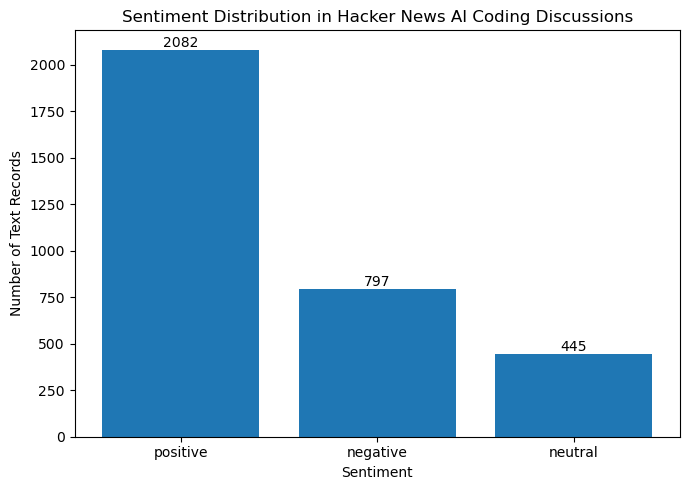

In [26]:
sentiment_counts = analysis_df["sentimentLabel"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Sentiment Distribution in Hacker News AI Coding Discussions")
plt.xlabel("Sentiment")
plt.ylabel("Number of Text Records")

for i, value in enumerate(sentiment_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

## Text preprocessing and common terms

The text is tokenised, lemmatised and filtered using stopwords so that common terms reflect meaningful discussion topics.

In [27]:
stop_words = set(stopwords.words("english"))

extra_stopwords = {
    "would", "could", "should", "also", "like", "just", "really",
    "think", "people", "thing", "things", "get", "got", "use",
    "using", "used", "one", "much", "many", "still", "even",
    "well", "make", "see", "know", "want", "going", "good",
    "need", "say", "said", "way", "something" ,"wa", "ha"
}

stop_words = stop_words | extra_stopwords

lemmatizer = WordNetLemmatizer()

def preprocess_text_for_terms(text):
    text = str(text).lower()
    words = re.findall(r"[a-z][a-z0-9_]{2,}", text)

    cleaned_words = []

    for word in words:
        word = lemmatizer.lemmatize(word)

        if word not in stop_words:
            cleaned_words.append(word)

    return cleaned_words


analysis_df["tokens"] = analysis_df["textClean"].apply(preprocess_text_for_terms)

word_counter = Counter()

for tokens in analysis_df["tokens"]:
    word_counter.update(tokens)

common_terms_df = pd.DataFrame(
    word_counter.most_common(30),
    columns=["term", "frequency"]
)

common_terms_df

,term,frequency
0,code,2696
1,claude,995
2,work,825
3,coding,778
4,time,740
5,tool,730
6,model,719
7,copilot,713
8,llm,692
9,agent,480


## Graph 
Plotting the graph for the most common terms.

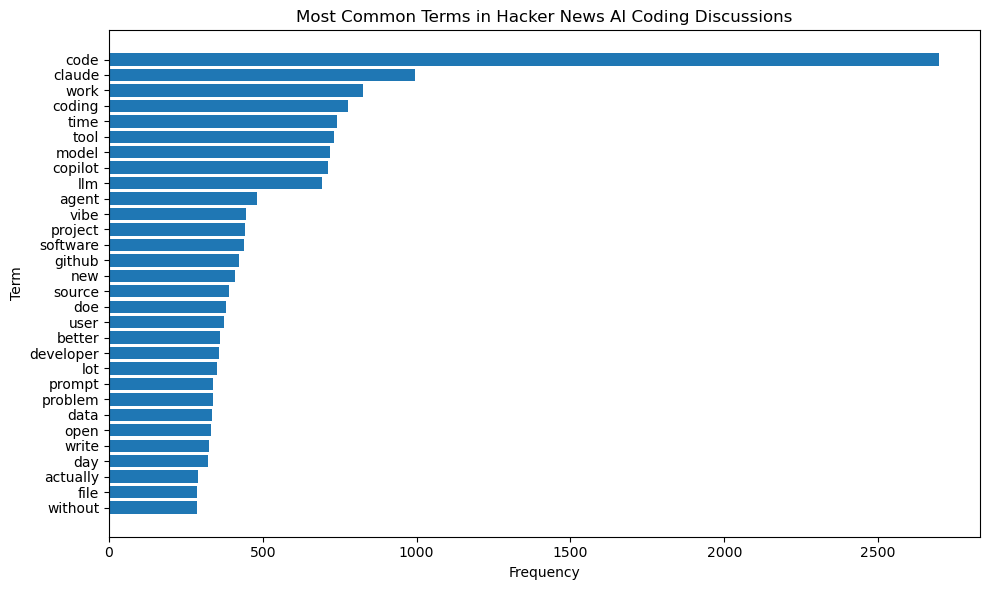

In [28]:
plt.figure(figsize=(10, 6))
plt.barh(
    common_terms_df["term"][::-1],
    common_terms_df["frequency"][::-1]
)

plt.title("Most Common Terms in Hacker News AI Coding Discussions")
plt.xlabel("Frequency")
plt.ylabel("Term")

plt.tight_layout()
plt.show()

## Positive and negative word clouds

Separate word clouds are created for positive and negative records to compare the language used in different sentiment groups.

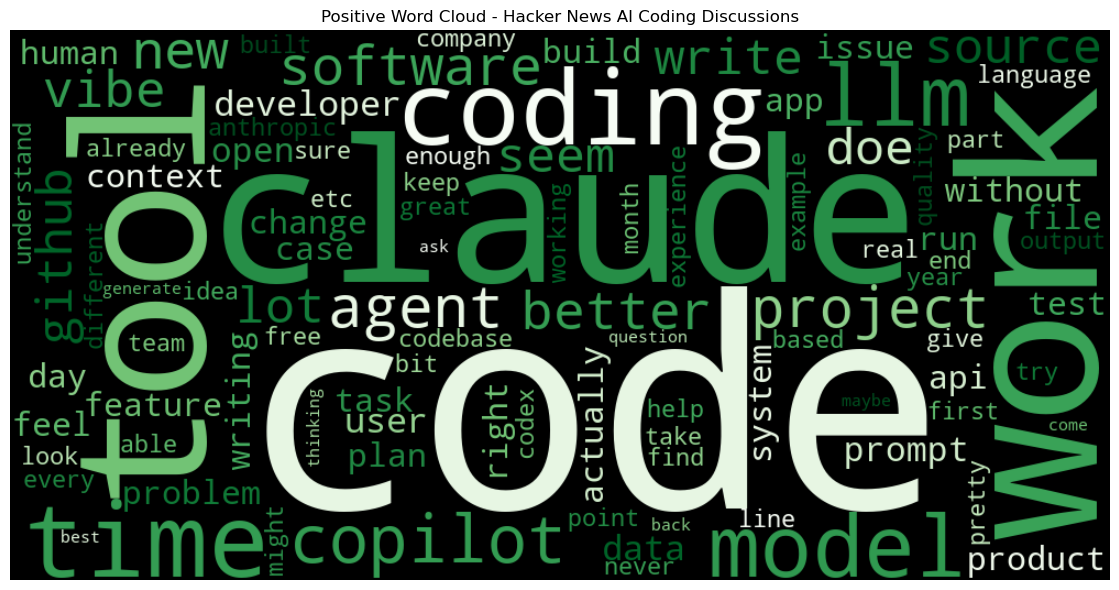

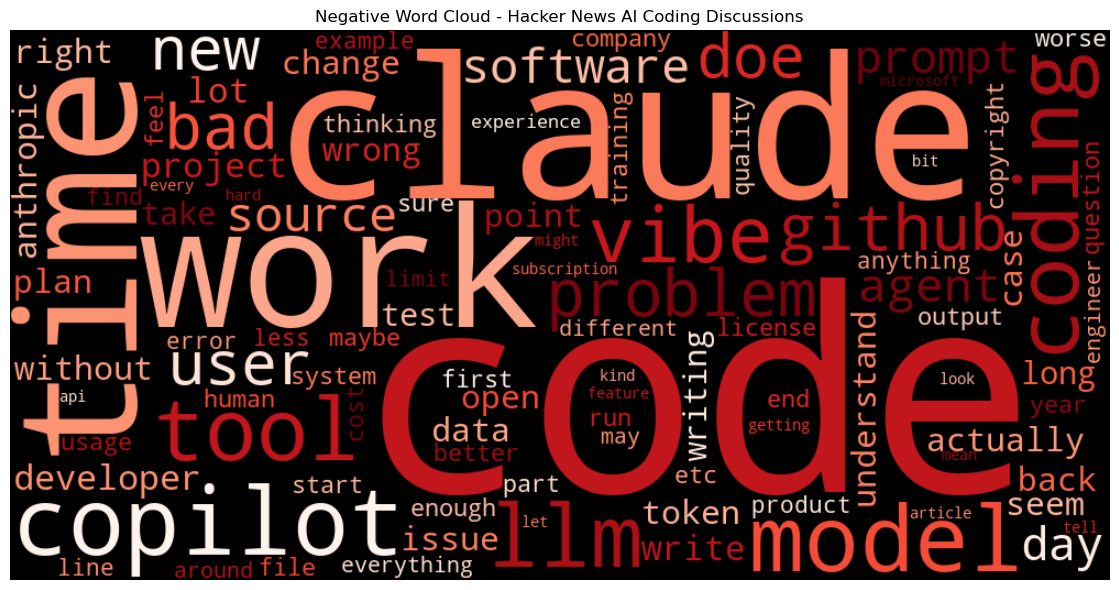

In [48]:
from wordcloud import WordCloud

# Make sure tokensText exists
analysis_df["tokensText"] = analysis_df["tokens"].apply(lambda words: " ".join(words))

# Split text by sentiment
positive_text = " ".join(
    analysis_df.loc[
        analysis_df["sentimentLabel"] == "positive",
        "tokensText"
    ].fillna("")
)

negative_text = " ".join(
    analysis_df.loc[
        analysis_df["sentimentLabel"] == "negative",
        "tokensText"
    ].fillna("")
)
positive_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="black",
    max_words=100,
    colormap="Greens",
    collocations=False
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Word Cloud - Hacker News AI Coding Discussions")
plt.tight_layout()
plt.show()
negative_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="black",
    max_words=100,
    colormap="Reds",
    collocations=False
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Word Cloud - Hacker News AI Coding Discussions")
plt.tight_layout()
plt.show()

## LDA topic modelling

LDA is used to discover common discussion topics in the Hacker News text without manually defining categories , this is just preparing LDA topic modelling.

In [45]:
lda_df = analysis_df.copy()

lda_df = lda_df[lda_df["tokensText"].notna()].copy()
lda_df = lda_df[lda_df["tokensText"].str.strip() != ""].copy()

print("Rows available for LDA:", len(lda_df))

lda_df[["textClean", "tokensText"]].head()

Rows available for LDA: 3322


,textClean,tokensText
0,GitHub Copilot,github copilot
1,To see all the 1100 comments you'll need to cl...,comment click bottom page href rel nofollow hr...
2,I've been using the alpha for the past 2 weeks...,alpha past week blown away copilot guess exact...
3,Hi HN we've been building GitHub Copilot toget...,building github copilot together incredibly ta...
4,I don't think we need to start looking for new...,start looking new career path yet example bug ...


## LDA topic words

The top words for each LDA topic are shown above  and used to assign readable topic labels and the data is trained


In [32]:
NUM_TOPICS = 6

vectorizer = CountVectorizer(
    max_df=0.90,
    min_df=5,
    max_features=1000
)

term_matrix = vectorizer.fit_transform(lda_df["tokensText"])

lda_model = LatentDirichletAllocation(
    n_components=NUM_TOPICS,
    random_state=42,
    learning_method="batch",
    max_iter=20
)

lda_model.fit(term_matrix)

print("LDA model trained.")
print("Documents:", term_matrix.shape[0])
print("Terms:", term_matrix.shape[1])

LDA model trained.
Documents: 3322
Terms: 1000


## LDA topic words

The top words for each LDA topic are shown below and used to assign readable topic labels.

In [33]:
def display_lda_topics(model, feature_names, top_n=12):
    topic_rows = []

    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-top_n:][::-1]
        top_words = [feature_names[i] for i in top_indices]

        topic_rows.append({
            "topicNumber": topic_idx,
            "topWords": ", ".join(top_words)
        })

    return pd.DataFrame(topic_rows)


feature_names = vectorizer.get_feature_names_out()

topics_df = display_lda_topics(
    lda_model,
    feature_names,
    top_n=12
)

topics_df

,topicNumber,topWords
0,0,"claude, code, model, plan, anthropic, token, u..."
1,1,"data, system, product, href, company, model, g..."
2,2,"code, llm, coding, tool, work, agent, write, v..."
3,3,"time, day, vibe, work, coding, lot, take, feel..."
4,4,"code, copilot, github, source, open, license, ..."
5,5,"file, run, code, tool, model, api, data, user,..."


## Topic labelling

Each LDA topic is given a short readable label based on its most important words.

In [34]:
TOPIC_LABELS = {
    0: "Claude and AI model discussion",
    1: "Companies, data and AI systems",
    2: "AI coding tools and agents",
    3: "Vibe coding and developer workflow",
    4: "GitHub Copilot, open source and licensing",
    5: "APIs, files and technical implementation",
}

topics_df["topicLabel"] = topics_df["topicNumber"].map(TOPIC_LABELS)

topics_df

,topicNumber,topWords,topicLabel
0,0,"claude, code, model, plan, anthropic, token, u...",Claude and AI model discussion
1,1,"data, system, product, href, company, model, g...","Companies, data and AI systems"
2,2,"code, llm, coding, tool, work, agent, write, v...",AI coding tools and agents
3,3,"time, day, vibe, work, coding, lot, take, feel...",Vibe coding and developer workflow
4,4,"code, copilot, github, source, open, license, ...","GitHub Copilot, open source and licensing"
5,5,"file, run, code, tool, model, api, data, user,...","APIs, files and technical implementation"


## Assign dominant topic

Each text record is assigned to the LDA topic with the highest probability score.

In [35]:
topic_probabilities = lda_model.transform(term_matrix)

lda_df["dominantTopic"] = topic_probabilities.argmax(axis=1)
lda_df["dominantTopicScore"] = topic_probabilities.max(axis=1)
lda_df["topicLabel"] = lda_df["dominantTopic"].map(TOPIC_LABELS)

print("Topic distribution:")
print(lda_df["topicLabel"].value_counts())

lda_df[["textClean", "sentimentLabel", "dominantTopic", "dominantTopicScore", "topicLabel"]].head()

Topic distribution:
topicLabel
AI coding tools and agents                   899
Vibe coding and developer workflow           654
Claude and AI model discussion               527
GitHub Copilot, open source and licensing    508
APIs, files and technical implementation     396
Companies, data and AI systems               338
Name: count, dtype: int64


,textClean,sentimentLabel,dominantTopic,dominantTopicScore,topicLabel
0,GitHub Copilot,neutral,4,0.722124,"GitHub Copilot, open source and licensing"
1,To see all the 1100 comments you'll need to cl...,positive,1,0.906032,"Companies, data and AI systems"
2,I've been using the alpha for the past 2 weeks...,positive,2,0.498189,AI coding tools and agents
3,Hi HN we've been building GitHub Copilot toget...,positive,3,0.513662,Vibe coding and developer workflow
4,I don't think we need to start looking for new...,negative,4,0.410888,"GitHub Copilot, open source and licensing"


## Topic distribution

Plotting a graph which shows which LDA topics appear most often in the Hacker News discussion.

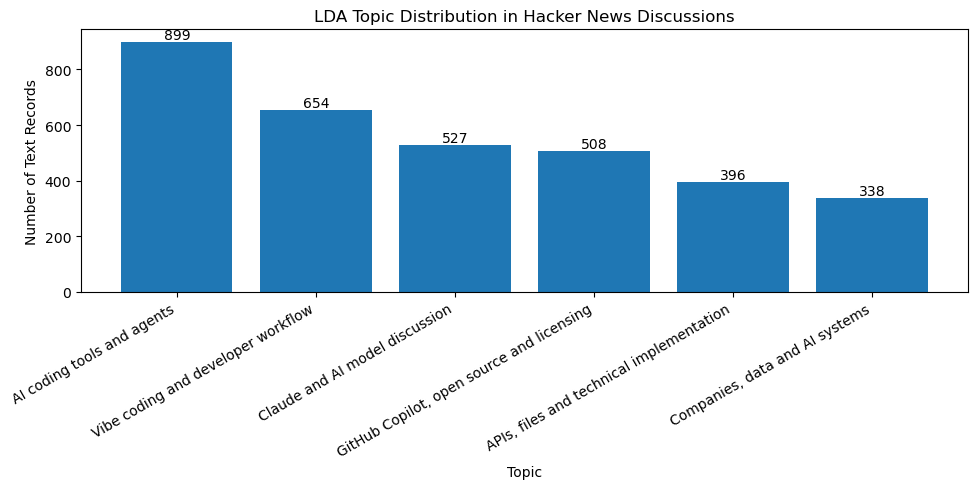

In [36]:
topic_counts = lda_df["topicLabel"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(topic_counts.index, topic_counts.values)

plt.title("LDA Topic Distribution in Hacker News Discussions")
plt.xlabel("Topic")
plt.ylabel("Number of Text Records")
plt.xticks(rotation=30, ha="right")

for i, value in enumerate(topic_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

## Sentiment by topic

This section compares positive, neutral and negative sentiment across the discovered LDA topics.

In [37]:
sentiment_topic_table = pd.crosstab(
    lda_df["topicLabel"],
    lda_df["sentimentLabel"]
)

sentiment_topic_table

sentimentLabel,negative,neutral,positive
topicLabel,,,
AI coding tools and agents,213,86,600
"APIs, files and technical implementation",60,71,265
Claude and AI model discussion,129,81,317
"Companies, data and AI systems",63,51,224
"GitHub Copilot, open source and licensing",150,90,268
Vibe coding and developer workflow,182,64,408


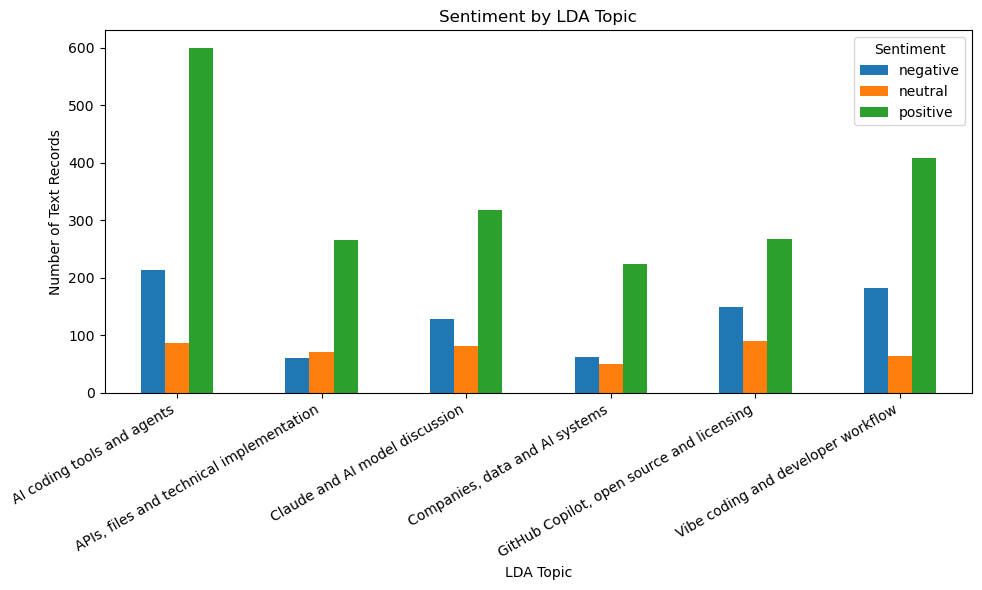

In [38]:
sentiment_topic_table.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sentiment by LDA Topic")
plt.xlabel("LDA Topic")
plt.ylabel("Number of Text Records")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

In [39]:
avg_sentiment_by_topic = (
    lda_df
    .groupby("topicLabel")["sentimentCompound"]
    .mean()
    .sort_values()
)

avg_sentiment_by_topic

topicLabel
GitHub Copilot, open source and licensing    0.170952
Claude and AI model discussion               0.252622
Vibe coding and developer workflow           0.260778
Companies, data and AI systems               0.327562
AI coding tools and agents                   0.336535
APIs, files and technical implementation     0.404188
Name: sentimentCompound, dtype: float64

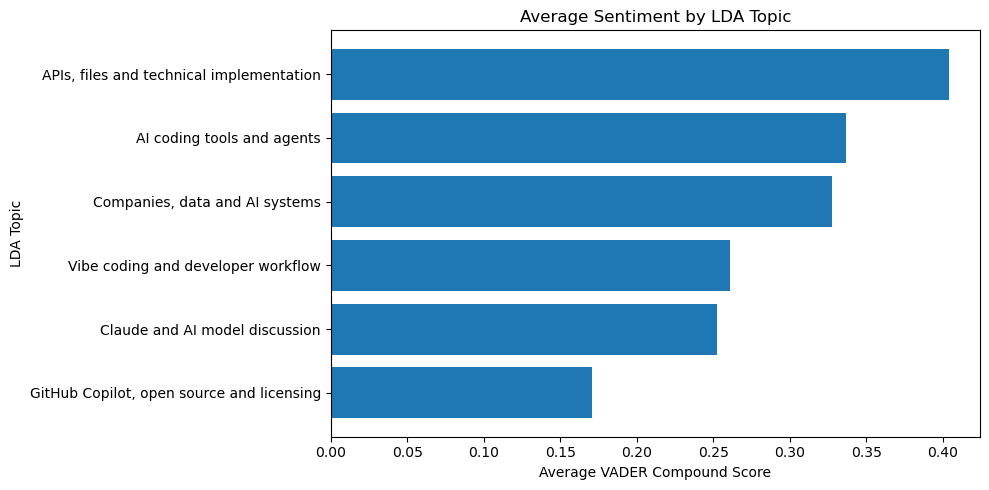

In [40]:
plt.figure(figsize=(10, 5))
plt.barh(avg_sentiment_by_topic.index, avg_sentiment_by_topic.values)

plt.title("Average Sentiment by LDA Topic")
plt.xlabel("Average VADER Compound Score")
plt.ylabel("LDA Topic")
plt.axvline(0, linestyle="--")

plt.tight_layout()
plt.show()

## Topics by search query

This section compares how discussion topics differ across the Hacker News search queries used for collection.

topicLabel,AI coding tools and agents,"APIs, files and technical implementation",Claude and AI model discussion,"Companies, data and AI systems","GitHub Copilot, open source and licensing",Vibe coding and developer workflow
sourceQuery,,,,,,
AI code security privacy,20,45,9,29,14,12
AI coding assistant,80,48,16,29,11,51
AI replacing programmers,17,3,0,11,1,8
AI software developer productivity,25,23,5,26,12,27
Claude Code,197,105,338,71,54,155
GitHub Copilot,121,82,82,88,368,110
OpenAI Codex,23,41,51,34,13,22
vibe coding,416,49,26,50,35,269


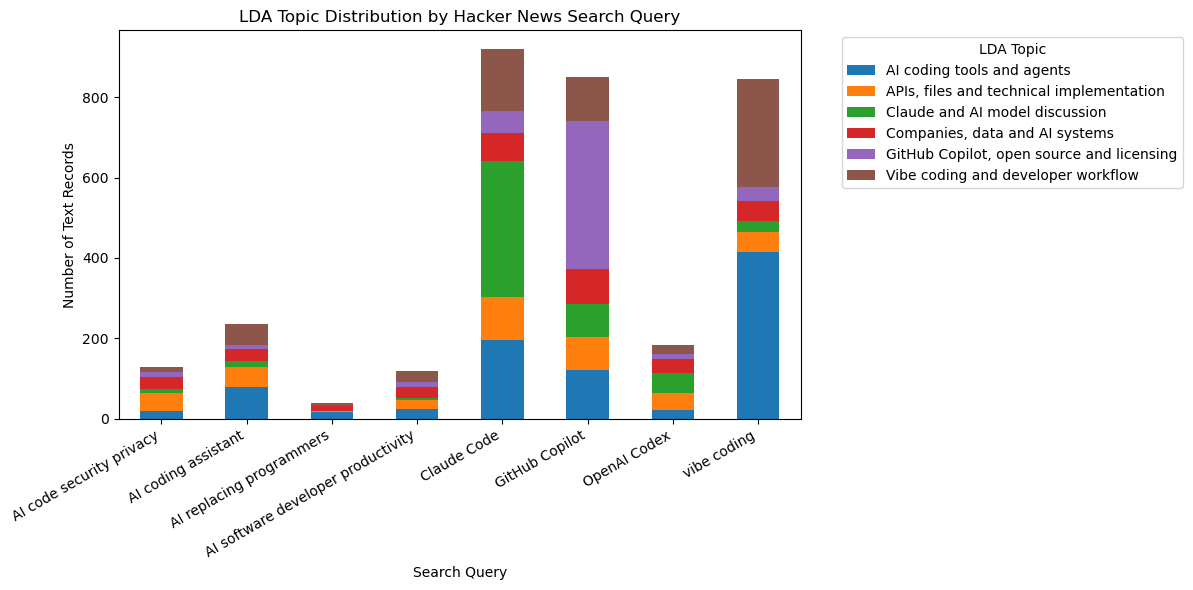

In [41]:
if "sourceQuery" in lda_df.columns:
    topic_query_table = pd.crosstab(
        lda_df["sourceQuery"],
        lda_df["topicLabel"]
    )

    display(topic_query_table)

    topic_query_table.plot(
        kind="bar",
        stacked=True,
        figsize=(12, 6)
    )

    plt.title("LDA Topic Distribution by Hacker News Search Query")
    plt.xlabel("Search Query")
    plt.ylabel("Number of Text Records")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="LDA Topic", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

## Sentiment by search query

This section compares average sentiment across the different Hacker News search queries.

sourceQuery
Claude Code                           0.257471
GitHub Copilot                        0.264948
vibe coding                           0.272378
OpenAI Codex                          0.290538
AI coding assistant                   0.319039
AI replacing programmers              0.442790
AI software developer productivity    0.460315
AI code security privacy              0.549444
Name: sentimentCompound, dtype: float64

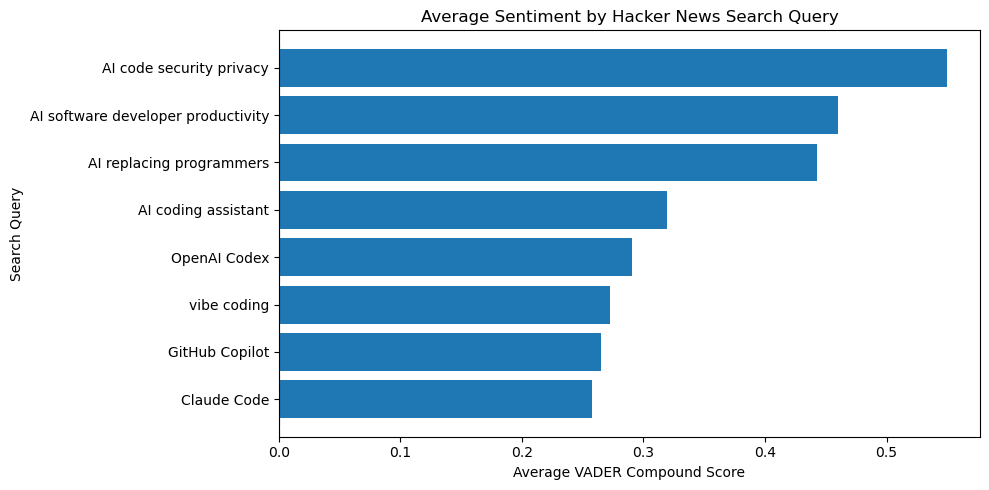

In [42]:
if "sourceQuery" in lda_df.columns:
    query_sentiment = (
        lda_df
        .groupby("sourceQuery")["sentimentCompound"]
        .mean()
        .sort_values()
    )

    display(query_sentiment)

    plt.figure(figsize=(10, 5))
    plt.barh(query_sentiment.index, query_sentiment.values)

    plt.title("Average Sentiment by Hacker News Search Query")
    plt.xlabel("Average VADER Compound Score")
    plt.ylabel("Search Query")
    plt.axvline(0, linestyle="--")

    plt.tight_layout()
    plt.show()

## Save final outputs

The final analysed dataset, LDA topic labels and summary statistics are saved for use in the report and cross-platform comparison.

In [43]:
analysis_output_path = OUTPUT_DIR / "hackernews_text_analysis.csv"
topics_output_path = OUTPUT_DIR / "hackernews_lda_topics.csv"
summary_output_path = OUTPUT_DIR / "hackernews_text_summary.json"

lda_df.to_csv(analysis_output_path, index=False)
topics_df.to_csv(topics_output_path, index=False)

summary = {
    "total_records": int(len(lda_df)),
    "num_topics": int(NUM_TOPICS),
    "sentiment_distribution": lda_df["sentimentLabel"].value_counts().to_dict(),
    "topic_distribution": lda_df["topicLabel"].value_counts().to_dict(),
    "average_sentiment": float(round(lda_df["sentimentCompound"].mean(), 4)),
    "average_sentiment_by_topic": (
        lda_df.groupby("topicLabel")["sentimentCompound"]
        .mean()
        .round(4)
        .to_dict()
    )
}

with open(summary_output_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved:")
print(analysis_output_path)
print(topics_output_path)
print(summary_output_path)

Saved:
C:\Users\aryan\Music\Social Media Analytics\social-media-2\data\processed\text_analysis\hackernews_text_analysis.csv
C:\Users\aryan\Music\Social Media Analytics\social-media-2\data\processed\text_analysis\hackernews_lda_topics.csv
C:\Users\aryan\Music\Social Media Analytics\social-media-2\data\processed\text_analysis\hackernews_text_summary.json
